In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from scipy import sparse
from scipy.sparse.linalg import spsolve
from scipy.signal import savgol_filter
from sklearn.decomposition import PCA
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV, cross_val_predict
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
import umap
from sklearn.manifold import TSNE

In [2]:
def als_baseline(y, D, L, p = 0.01, niter = 10):
    """
    Asymmetric Least Squares baseline correction.
    
    Parameters:
        y    : spectrum intensity array
        lam  : smoothness (1e3 – 1e7); higher = smoother baseline
        p    : asymmetry (0.001 – 0.1); lower = baseline hugs the bottom
        niter: number of iterations
    """
    w = np.ones(L)

    for _ in range(niter):
        W = sparse.diags(w)
        Z = W + D
        z = spsolve(Z, w*y)
        w = p * (y > z) + (1 - p) * (y <= z)
    return z

In [3]:
df = pd.read_csv("02_feature_matrix_raw_T.csv", header = 0)

dataFrame = df.drop(columns=["Sample_ID", "Replica", "Origin", "Type"])

labels = (["Cotton"]*14 + ["Acrylic"]*18 + ["Nylon"]*18 + ["PP/PE"]*8 + ["Polyester"]*17 + ["Silk"]*11 + ["Wool"]*23)

ranges = [(24, 38), (50, 68), (70, 88), (88, 96), (96, 113), (125, 136), (137, 160)]
indices = np.concatenate([np.arange(s, e) for s, e in ranges])
spectrums_labeled = dataFrame.iloc[indices].reset_index(drop=True).copy()
spectrums_labeled.insert(loc = 2, column = "Labels", value = labels)
spectrums_labeled.iloc[:, :15].head(20)


,Spectrum_ID,Subtype,Labels,4000.0,3999.0,3998.0,3997.0,3996.0,3995.0,3994.0,3993.0,3992.0,3991.0,3990.0,3989.0
0,25,Cotton,Cotton,99.10,99.11,99.12,99.11,99.10,99.09,99.06,99.04,99.03,99.03,99.04,99.05
1,26,Cotton,Cotton,99.26,99.28,99.30,99.31,99.32,99.32,99.31,99.30,99.29,99.28,99.27,99.26
2,27,Cotton,Cotton,99.89,99.89,99.89,99.89,99.89,99.89,99.90,99.91,99.92,99.94,99.95,99.95
3,28,Cotton,Cotton,99.59,99.60,99.61,99.62,99.61,99.60,99.60,99.60,99.60,99.60,99.60,99.60
4,29,Cotton,Cotton,100.71,100.72,100.74,100.75,100.77,100.77,100.76,100.75,100.73,100.72,100.71,100.70
5,30,Cotton,Cotton,99.95,99.96,99.96,99.95,99.94,99.92,99.90,99.89,99.88,99.86,99.85,99.85
6,31,Cotton,Cotton,101.33,101.33,101.34,101.35,101.36,101.36,101.37,101.37,101.37,101.37,101.35,101.34
7,32,Cotton,Cotton,100.02,100.02,100.02,100.03,100.03,100.03,100.02,100.02,100.01,100.00,99.97,99.95
8,33,Cotton,Cotton,100.45,100.47,100.48,100.49,100.48,100.47,100.46,100.45,100.45,100.46,100.46,100.46
9,34,Cotton,Cotton,100.07,100.07,100.06,100.04,100.02,100.00,99.99,99.99,99.99,100.00,100.01,100.01


In [4]:
spectrums = spectrums_labeled.drop(columns=["Subtype"])

L = spectrums.iloc[:, 2:].shape[1]
D = sparse.diags([1, -2, 1], [0, 1, 2], shape=(L - 2, L))
D = 1e5 * D.T @ D 

corrected = spectrums.copy()

for i in range(spectrums.shape[0]):
    y = spectrums.iloc[i, 2:].values.astype(float)
    baseline = als_baseline(y, D, L)
    corrected.iloc[i, 2:] = y - baseline

meta = corrected.iloc[:, :2].reset_index(drop=True)
values = corrected.iloc[:, 2:].astype(float)
    
normalized = values.copy()

for i in range(values.shape[0]):
    row = values.iloc[i].values
    normalized.iloc[i, :] = (row - row.mean())/row.std()

smoothed = normalized.copy()

for i in range(normalized.shape[0]):
    smoothed.iloc[i, :] = savgol_filter(normalized.iloc[i, :], window_length=9, polyorder=3)

final_df = pd.concat([meta, smoothed], axis=1)

final_df.iloc[:20, :6].head(20)

/opt/anaconda3/lib/python3.11/site-packages/scipy/sparse/_construct.py:543: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
Note: In Python 3.11, this warning can be generated by a call of scipy.sparse.diags(), but the code indicated in the warning message will refer to an internal call of scipy.sparse.diags_array(). If that happens, check your code for the use of diags().
  A = diags_array(diagonals, offsets=offsets, shape=shape, dtype=dtype)
/var/folders/1m/_kc705z91wn9rgljb4jv9m5c0000gp/T/ipykernel_77340/1367918231.py:16: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  z = spsolve(Z, w*y)


,Spectrum_ID,Labels,4000.0,3999.0,3998.0,3997.0
0,25,Cotton,-0.622644,-0.612657,-0.610001,-0.613199
1,26,Cotton,-0.615384,-0.601185,-0.590786,-0.584005
2,27,Cotton,-0.581537,-0.581484,-0.581587,-0.581481
3,28,Cotton,-0.639473,-0.626938,-0.620960,-0.619838
4,29,Cotton,-0.629731,-0.620984,-0.612284,-0.604668
5,30,Cotton,-0.632839,-0.624660,-0.625329,-0.632624
6,31,Cotton,-0.659039,-0.656144,-0.651993,-0.647204
7,32,Cotton,-0.565450,-0.563970,-0.562109,-0.560645
8,33,Cotton,-0.622046,-0.595300,-0.582625,-0.580772
9,34,Cotton,-0.576293,-0.576736,-0.580609,-0.586606


In [8]:
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)
num_classes = len(np.unique(labels_encoded))

X = final_df.iloc[:, 2:].to_numpy(dtype=np.float32)
X = X[:, None, :]

X_tensor = torch.tensor(X, dtype=torch.float32)
y_tensor = torch.tensor(labels_encoded, dtype=torch.long)


k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)
epochs = 100

fold_accuracies = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, labels_encoded)):

    X_train, X_val = X_tensor[train_idx], X_tensor[val_idx]
    y_train, y_val = y_tensor[train_idx], y_tensor[val_idx]

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    val_dataset   = torch.utils.data.TensorDataset(X_val, y_val)
    train_loader  = torch.utils.data.DataLoader(train_dataset, batch_size=16, shuffle=True)
    val_loader    = torch.utils.data.DataLoader(val_dataset, batch_size=16, shuffle=False)

    # model = nn.Sequential(
    #     nn.Conv1d(1, 8, kernel_size=11, padding=5),
    #     nn.BatchNorm1d(8),
    #     nn.ReLU(),
    #     nn.AdaptiveAvgPool1d(32),
    #     nn.Dropout(0.4),

    #     nn.Conv1d(8, 16, kernel_size=5, padding=2),
    #     nn.BatchNorm1d(16),
    #     nn.ReLU(),
    #     nn.AdaptiveAvgPool1d(1),
    #     nn.Flatten(),
    #     nn.Dropout(0.5),

    #     nn.Linear(16, num_classes)
    # )
    model = nn.Sequential(
        nn.Conv1d(in_channels=1, out_channels=16, kernel_size=7, padding=3),
        nn.BatchNorm1d(16),
        nn.ReLU(),
        nn.MaxPool1d(kernel_size=2),
        nn.Dropout(p=0.3),

        nn.Conv1d(16, 32, kernel_size=5, padding=2),
        nn.BatchNorm1d(32),
        nn.ReLU(),
        nn.MaxPool1d(kernel_size=2),
        nn.Dropout(p=0.3),

        nn.AdaptiveAvgPool1d(1),
        nn.Flatten(),

        nn.Linear(32, 64),
        nn.ReLU(),
        nn.Dropout(p=0.5),
        nn.Linear(64, num_classes)
    )

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-3)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for xb, yb in train_loader:
            logits = model(xb)
            loss = criterion(logits, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        model.eval()
        correct, total = 0, 0
        with torch.no_grad():
            for xb, yb in val_loader:
                preds = model(xb).argmax(dim=1)
                correct += (preds == yb).sum().item()
                total += yb.size(0)

        val_acc = correct / total
        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss} | Val Acc: {val_acc}")

        scheduler.step()

    fold_accuracies.append(val_acc)
    print(f"Fold {fold+1} Final Val Accuracy: {val_acc}")

print(f"Per-fold accuracies: {[f'{a}' for a in fold_accuracies]}")
print(f"Mean accuracy: {np.mean(fold_accuracies)} ± {np.std(fold_accuracies)}")

Epoch 1/100 | Loss: 11.988826274871826 | Val Acc: 0.18181818181818182
Epoch 2/100 | Loss: 11.686102032661438 | Val Acc: 0.18181818181818182
Epoch 3/100 | Loss: 11.677448272705078 | Val Acc: 0.18181818181818182
Epoch 4/100 | Loss: 11.536609768867493 | Val Acc: 0.18181818181818182
Epoch 5/100 | Loss: 11.453033328056335 | Val Acc: 0.18181818181818182
Epoch 6/100 | Loss: 11.40591847896576 | Val Acc: 0.18181818181818182
Epoch 7/100 | Loss: 11.475791096687317 | Val Acc: 0.18181818181818182
Epoch 8/100 | Loss: 11.278457045555115 | Val Acc: 0.18181818181818182
Epoch 9/100 | Loss: 11.36586618423462 | Val Acc: 0.22727272727272727
Epoch 10/100 | Loss: 11.17590069770813 | Val Acc: 0.45454545454545453
Epoch 11/100 | Loss: 11.091435313224792 | Val Acc: 0.5454545454545454
Epoch 12/100 | Loss: 11.048925638198853 | Val Acc: 0.45454545454545453
Epoch 13/100 | Loss: 11.184941172599792 | Val Acc: 0.36363636363636365
Epoch 14/100 | Loss: 11.102532863616943 | Val Acc: 0.36363636363636365
Epoch 15/100 | Loss

In [31]:
pca_full = PCA()
pca_full.fit(final_df.iloc[:, 2:].values)

# Calculate cumulative variance explained
cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)

# Find number of components for 95%, 99% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
n_components_99 = np.argmax(cumulative_variance >= 0.99) + 1
print(n_components_95)
print(n_components_99)

12
27


(109, 12)


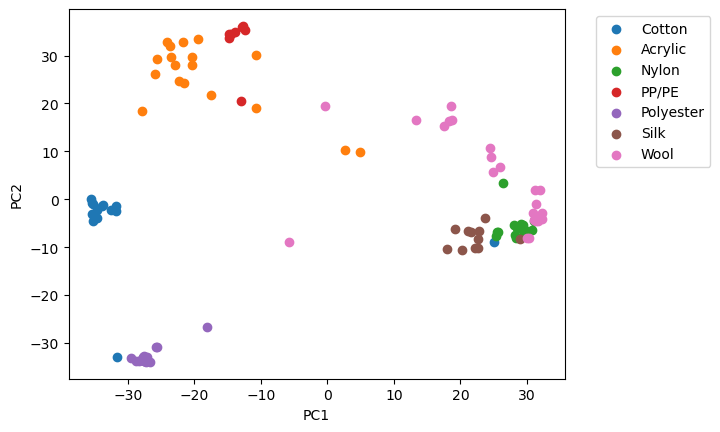

In [10]:
labels = final_df["Labels"]
codes, uniques = pd.factorize(labels)

pca = PCA(n_components=12)
pca_data = pca.fit_transform(final_df.iloc[:, 2:].values)
print(pca_data.shape)

for lab in uniques:
    idx = labels == lab
    plt.scatter(pca_data[idx, 0], pca_data[idx, 1], label=lab)

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

In [16]:
param_grid = {"C": [0.1, 0.5, 1, 2, 5, 10], "gamma": [0.0005, 0.001, 0.005, 0.01, 0.02, 0.05, 0.1, "scale"], "kernel": ["rbf"]}

svm = SVC()

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=57)

grid = GridSearchCV(estimator=svm, param_grid=param_grid, cv=skf, scoring="accuracy")
grid.fit(pca_data, labels)

print("Best parameters:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)

Best parameters: {'C': 0.5, 'gamma': 0.0005, 'kernel': 'rbf'}
Best CV accuracy: 0.9636363636363636


In [17]:
X = final_df.iloc[:, 2:].to_numpy(dtype=np.float32)
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

umap_reducer = umap.UMAP(n_components=30, n_neighbors=10, min_dist=0.1, random_state=42)
umap_data = umap_reducer.fit_transform(X, y=labels_encoded) 

svm = SVC(kernel = "rbf", C=0.5, gamma=0.0005)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=57)

umap_scores = cross_val_score(svm, umap_data, labels, cv=skf, scoring="accuracy")
umap_pred = cross_val_predict(svm, umap_data, labels, cv=skf)
print(f"UMAP+SVM:  {umap_scores.mean()} ± {umap_scores.std()}")

/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP+SVM:  0.9727272727272727 ± 0.022268088570756146


/opt/anaconda3/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


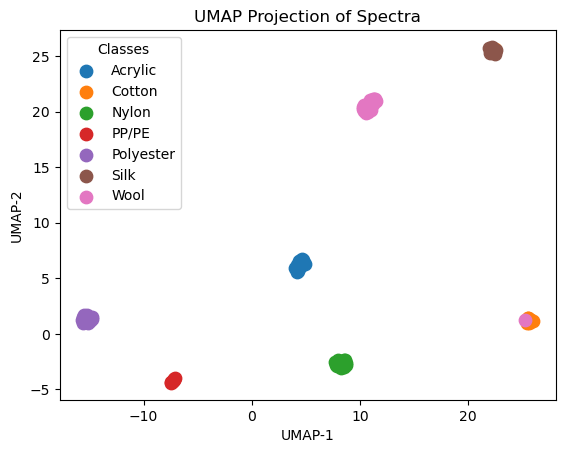

In [18]:
umap_vis = umap.UMAP(
    n_components=2,
    n_neighbors=10,
    min_dist=0.1,
    random_state=42
)

X_umap_2d = umap_vis.fit_transform(X, y=labels_encoded)

for class_idx, class_name in enumerate(le.classes_):

    mask = labels_encoded == class_idx

    plt.scatter(
        X_umap_2d[mask, 0],
        X_umap_2d[mask, 1],
        s=80,
        label=class_name
    )

plt.xlabel("UMAP-1")
plt.ylabel("UMAP-2")
plt.title("UMAP Projection of Spectra")

plt.legend(title="Classes")

plt.show()

In [19]:
tsne_reducer = TSNE(n_components=3, perplexity=15, random_state=42)
tsne_data = tsne_reducer.fit_transform(X)

tsne_scores = cross_val_score(svm, tsne_data, labels, cv=skf, scoring="accuracy")
tsne_pred   = cross_val_predict(svm, tsne_data, labels, cv=skf)
print(f"t-SNE+SVM: {tsne_scores.mean()} ± {tsne_scores.std()}")

t-SNE+SVM: 0.9181818181818183 ± 0.06030226891555271


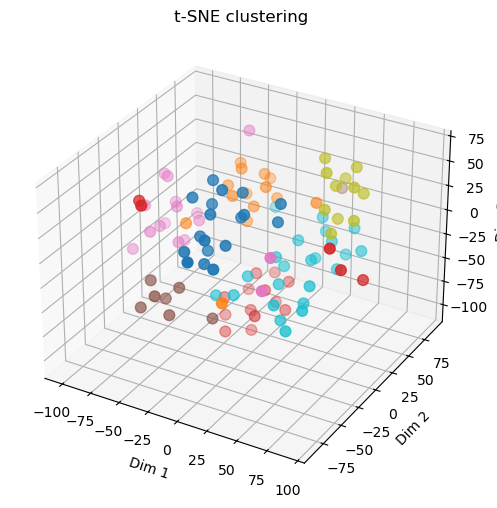

In [24]:
fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(tsne_data[:, 0], tsne_data[:, 1], tsne_data[:, 2], c=labels_encoded, cmap="tab10", s=60)

ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.set_zlabel("Dim 3")
ax.set_title("t-SNE clustering")

plt.show()

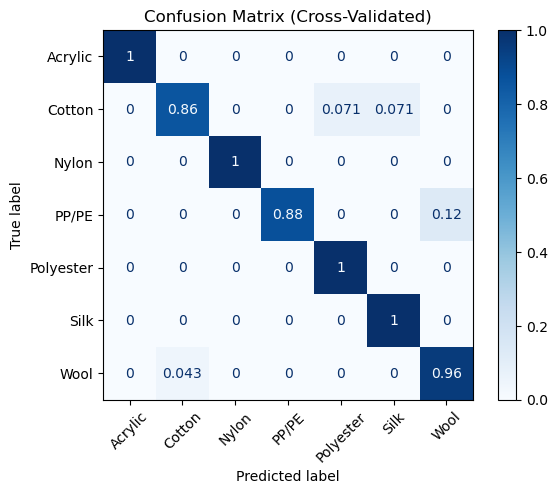


Classification Report:

              precision    recall  f1-score   support

     Acrylic       1.00      1.00      1.00        18
      Cotton       0.92      0.86      0.89        14
       Nylon       1.00      1.00      1.00        18
       PP/PE       1.00      0.88      0.93         8
   Polyester       0.94      1.00      0.97        17
        Silk       0.92      1.00      0.96        11
        Wool       0.96      0.96      0.96        23

    accuracy                           0.96       109
   macro avg       0.96      0.96      0.96       109
weighted avg       0.96      0.96      0.96       109

Fold accuracies: [0.95454545 0.95454545 0.90909091 1.         1.        ]
Mean accuracy: 0.9636363636363636
Std deviation: 0.034015067152490384


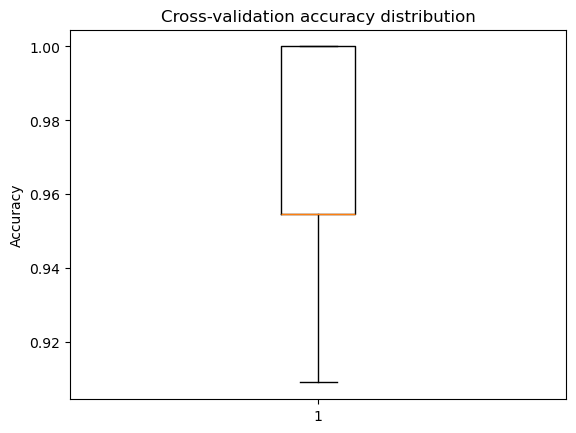

In [25]:
svm = SVC(kernel = "rbf", C=0.5, gamma=0.0005)

scores = cross_val_score(svm, pca_data, labels, cv=skf, scoring="accuracy")

# cross-validated predictions
y_pred = cross_val_predict(svm, pca_data, labels, cv=skf)

# confusion matrix
cm = confusion_matrix(labels, y_pred, normalize="true")

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=np.unique(labels))
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Confusion Matrix (Cross-Validated)")
plt.show()

# classification report
print("\nClassification Report:\n")
print(classification_report(labels, y_pred))

print("Fold accuracies:", scores)
print("Mean accuracy:", np.mean(scores))
print("Std deviation:", np.std(scores)) 

plt.boxplot(scores)
plt.title("Cross-validation accuracy distribution")
plt.ylabel("Accuracy")
plt.show()

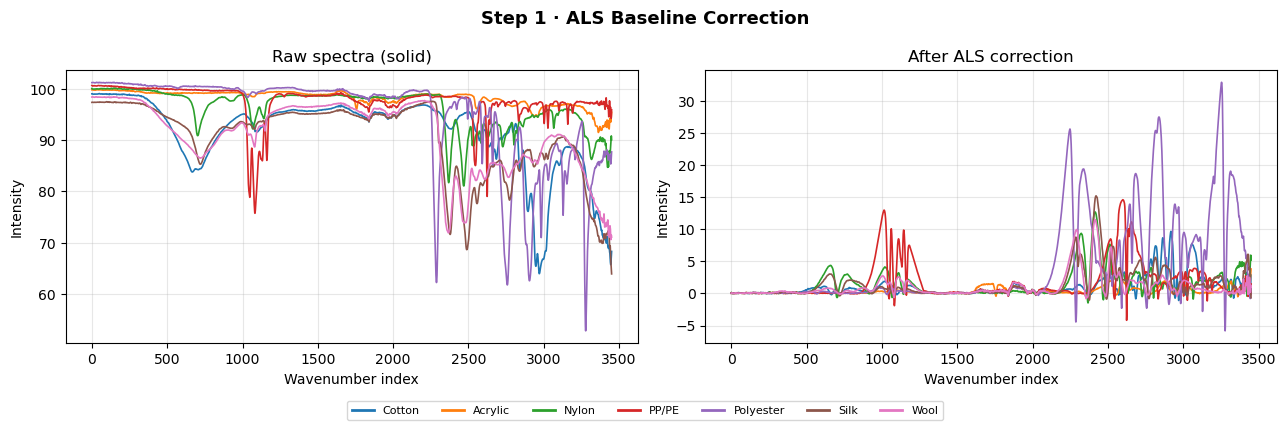

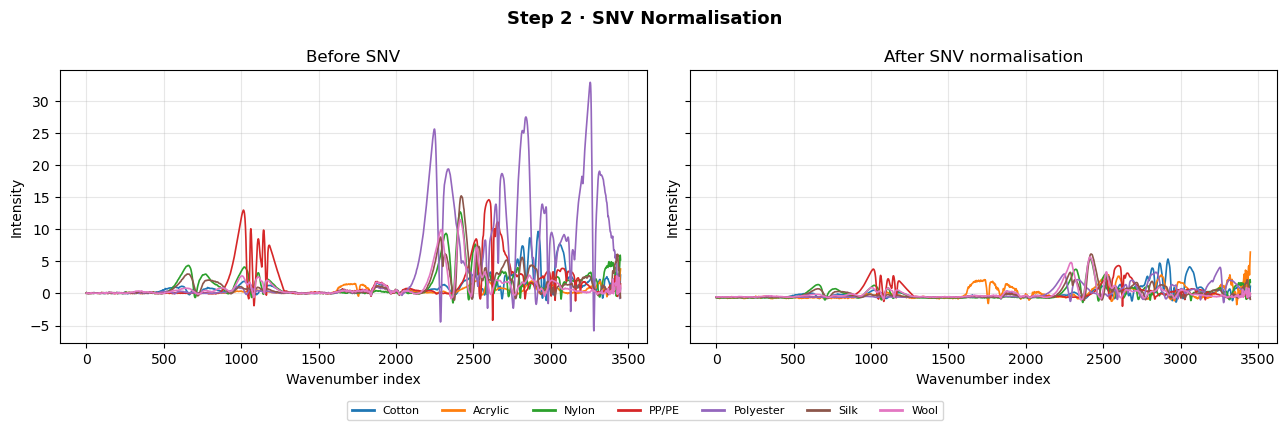

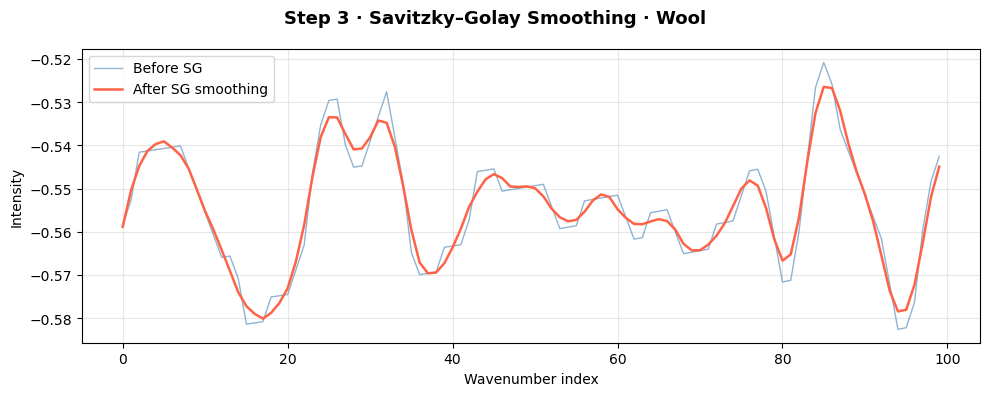

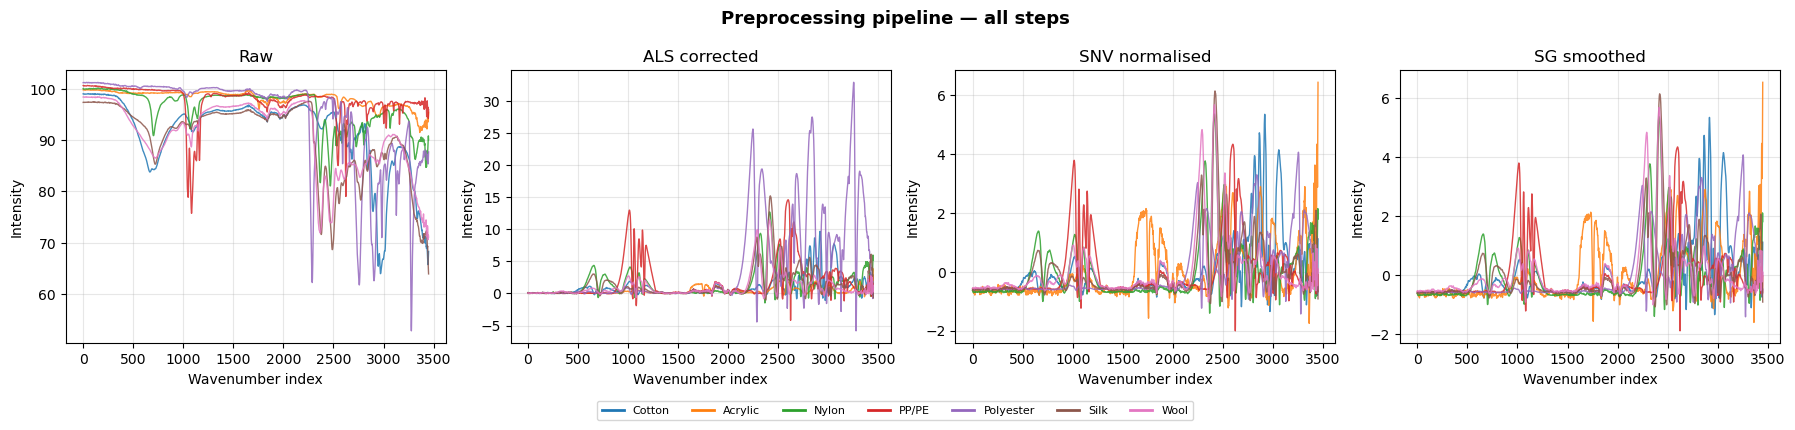

In [28]:
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D

plt.style.use("default")

CLASS_COLORS = {
    "Cotton":    "#1f77b4",
    "Acrylic":   "#ff7f0e",
    "Nylon":     "#2ca02c",
    "PP/PE":     "#d62728",
    "Polyester": "#9467bd",
    "Silk":      "#8c564b",
    "Wool":      "#e377c2",
}
CLASSES = list(CLASS_COLORS.keys())


rep_indices = {}
for cls in CLASSES:
    idx = spectrums_labeled[spectrums_labeled["Labels"] == cls].index[0]
    rep_indices[cls] = idx

wavenumbers = np.arange(spectrums.shape[1] - 2)

legend_handles = [Line2D([0], [0], color=CLASS_COLORS[c], lw=2, label=c) for c in CLASSES]



fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), sharey=False)
fig.suptitle("Step 1 · ALS Baseline Correction", fontsize=13, fontweight="bold")

for cls in CLASSES:
    i = rep_indices[cls]
    c = CLASS_COLORS[cls]
    y_raw = spectrums.iloc[i, 2:].values.astype(float)
    baseline = y_raw - corrected.iloc[i, 2:].values.astype(float)
    ax1.plot(wavenumbers, y_raw,    color=c, lw=1.2, label=cls)
    ax2.plot(wavenumbers, corrected.iloc[i, 2:].values.astype(float), color=c, lw=1.2)

ax1.set_title("Raw spectra (solid)")
ax2.set_title("After ALS correction")
for ax in (ax1, ax2):
    ax.set_xlabel("Wavenumber index")
    ax.set_ylabel("Intensity")
    ax.grid(True, alpha=0.3)

fig.legend(handles=legend_handles, loc="lower center", ncol=7,
           fontsize=8, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()


fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4), sharey=True)  
fig.suptitle("Step 2 · SNV Normalisation", fontsize=13, fontweight="bold")

for cls in CLASSES:
    i = rep_indices[cls]
    c = CLASS_COLORS[cls]
    ax1.plot(wavenumbers, corrected.iloc[i, 2:].values.astype(float),  color=c, lw=1.2, label=cls)
    ax2.plot(wavenumbers, normalized.iloc[i].values.astype(float),     color=c, lw=1.2)

ax1.set_title("Before SNV")
ax2.set_title("After SNV normalisation")
for ax in (ax1, ax2):
    ax.set_xlabel("Wavenumber index")
    ax.set_ylabel("Intensity")
    ax.grid(True, alpha=0.3)

fig.legend(handles=legend_handles, loc="lower center", ncol=7,
           fontsize=8, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()



SG_CLASS = "Wool"
i = rep_indices[SG_CLASS]
zoom = slice(0, 100) 

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle(f"Step 3 · Savitzky–Golay Smoothing · {SG_CLASS}",
             fontsize=13, fontweight="bold")

ax.plot(wavenumbers[zoom], normalized.iloc[i, zoom].values.astype(float),
        color="steelblue", lw=1.0, alpha=0.6, label="Before SG")
ax.plot(wavenumbers[zoom], smoothed.iloc[i, zoom].values.astype(float),
        color="tomato",    lw=1.8, label="After SG smoothing")

ax.set_xlabel("Wavenumber index")
ax.set_ylabel("Intensity")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



stage_labels = ["Raw", "ALS corrected", "SNV normalised", "SG smoothed"]

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
fig.suptitle("Preprocessing pipeline — all steps", fontsize=13, fontweight="bold")

for cls in CLASSES:
    i = rep_indices[cls]
    c = CLASS_COLORS[cls]
    stages_data = [
        spectrums.iloc[i, 2:].values.astype(float),
        corrected.iloc[i, 2:].values.astype(float),
        normalized.iloc[i].values.astype(float),
        smoothed.iloc[i].values.astype(float),
    ]
    for ax, data in zip(axes, stages_data):
        ax.plot(wavenumbers, data, color=c, lw=1.0, alpha=0.85, label=cls)

for ax, title in zip(axes, stage_labels):
    ax.set_title(title)
    ax.set_xlabel("Wavenumber index")
    ax.set_ylabel("Intensity")
    ax.grid(True, alpha=0.3)

fig.legend(handles=legend_handles, loc="lower center", ncol=7,
           fontsize=8, bbox_to_anchor=(0.5, -0.06))
plt.tight_layout()
plt.show()

## Wallahi we visualize

### Which IDs get visualized

In [33]:
selected_visual_ids = [0,1,3] # For the 4 different graphs
selected_comparison_ids = [0,1] # For comparison graphs

### Baseline Visualization

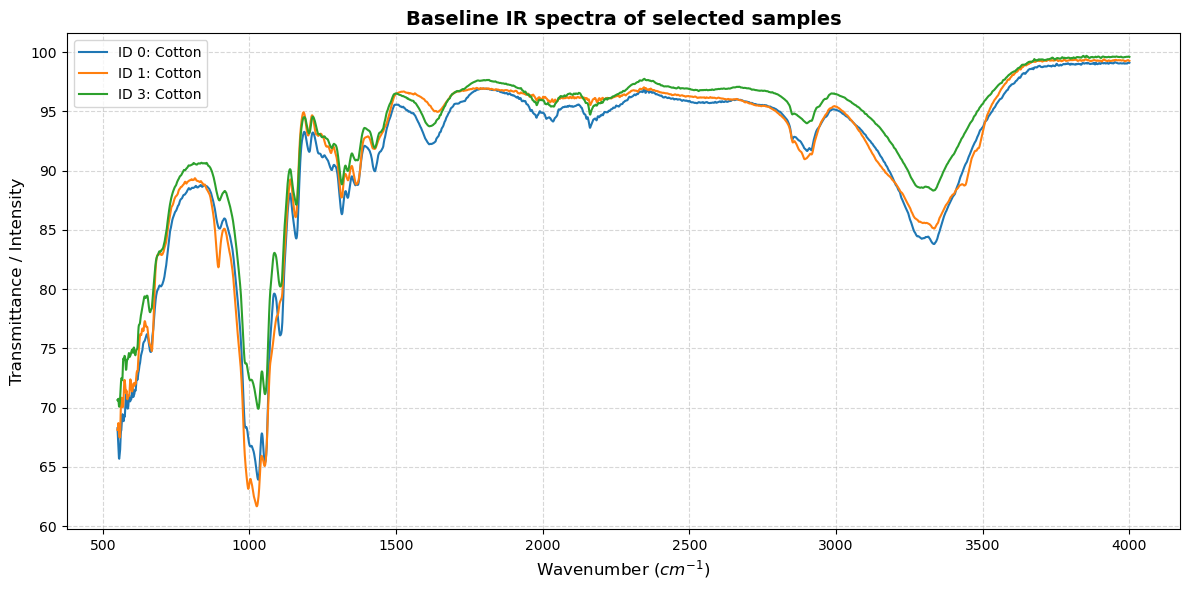

In [34]:
# ------------------ Baseline Visualization ------------------

baseline_wavenumber_cols = spectrums.columns.drop(["Spectrum_ID", "Labels"])
baseline_wavenumbers = baseline_wavenumber_cols.astype(float)

baseline_selected_spectra = spectrums.loc[selected_visual_ids, baseline_wavenumber_cols]
baseline_compare_spectra = spectrums.loc[selected_comparison_ids, baseline_wavenumber_cols]

plt.figure(figsize=(12, 6))
plt.plot(baseline_wavenumbers, baseline_selected_spectra.T)
plt.title("Baseline IR spectra of selected samples", fontsize=14, fontweight='bold')
plt.xlabel("Wavenumber ($cm^{-1}$)", fontsize=12)
plt.ylabel("Transmittance / Intensity", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
legend_labels = [f"ID {sid}: {spectrums.loc[sid, 'Labels']}" for sid in selected_visual_ids]
plt.legend(legend_labels, loc="best")
plt.tight_layout()


### Corrected Visualization

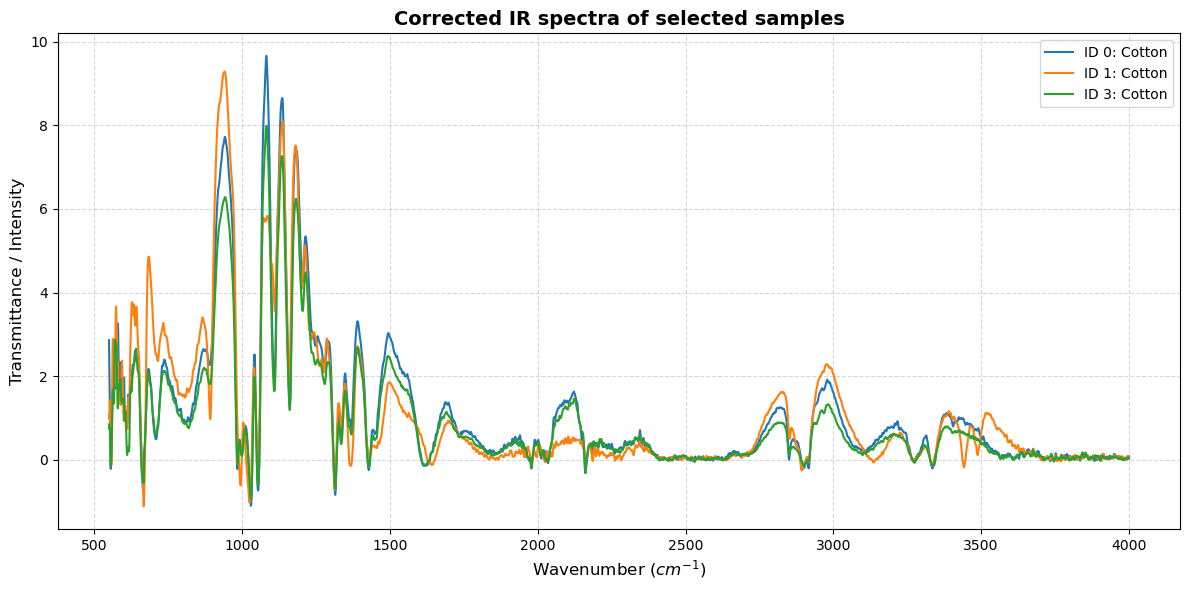

In [35]:
corrected_wavenumber_cols = values.columns
corrected_wavenumbers = corrected_wavenumber_cols.astype(float)

corrected_selected_spectra = values.loc[selected_visual_ids, baseline_wavenumber_cols]
corrected_compare_spectra = values.loc[selected_comparison_ids, baseline_wavenumber_cols]

plt.figure(figsize=(12, 6))
plt.plot(corrected_wavenumbers, corrected_selected_spectra.T)
plt.title("Corrected IR spectra of selected samples", fontsize=14, fontweight='bold')
plt.xlabel("Wavenumber ($cm^{-1}$)", fontsize=12)
plt.ylabel("Transmittance / Intensity", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
legend_labels = [f"ID {sid}: {spectrums.loc[sid, 'Labels']}" for sid in selected_visual_ids]
plt.legend(legend_labels, loc="best")
plt.tight_layout()

### Normalized Visualization

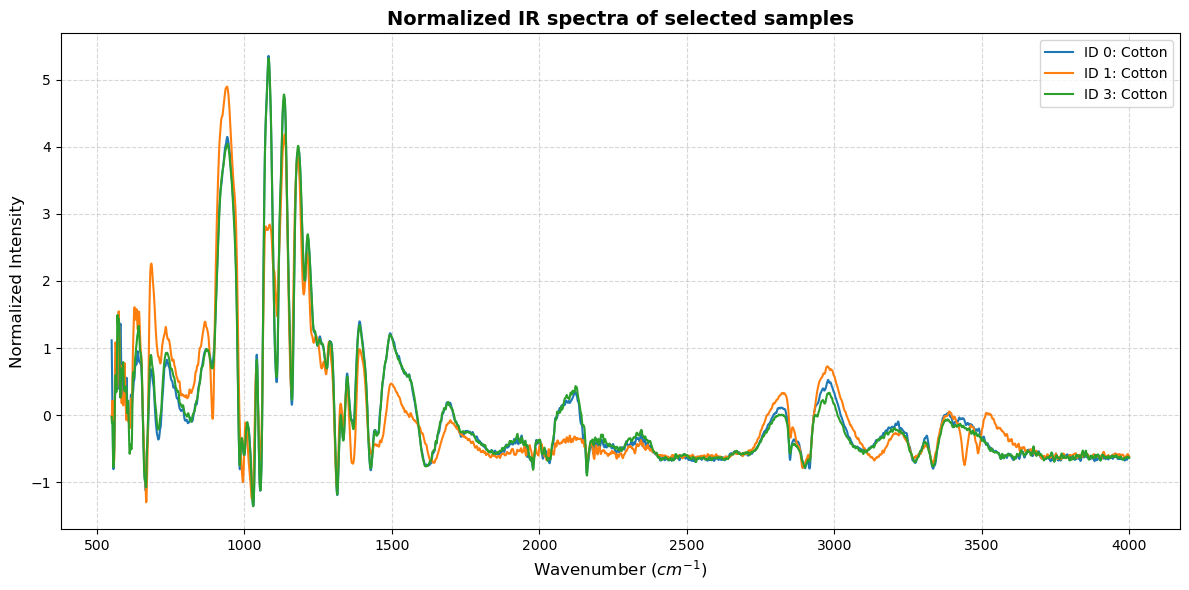

In [36]:
normalized_wavenumber_cols = normalized.columns
normalized_wavenumbers = normalized_wavenumber_cols.astype(float)

normalized_selected_spectra = normalized.loc[selected_visual_ids, baseline_wavenumber_cols]
normalized_compare_spectra = normalized.loc[selected_comparison_ids, baseline_wavenumber_cols]

plt.figure(figsize=(12, 6))
plt.plot(normalized_wavenumbers, normalized_selected_spectra.T)
plt.title("Normalized IR spectra of selected samples", fontsize=14, fontweight='bold')
plt.xlabel("Wavenumber ($cm^{-1}$)", fontsize=12)
plt.ylabel("Normalized Intensity", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
legend_labels = [f"ID {sid}: {spectrums.loc[sid, 'Labels']}" for sid in selected_visual_ids]
plt.legend(legend_labels, loc="best")
plt.tight_layout()

### Smoothed Visualization

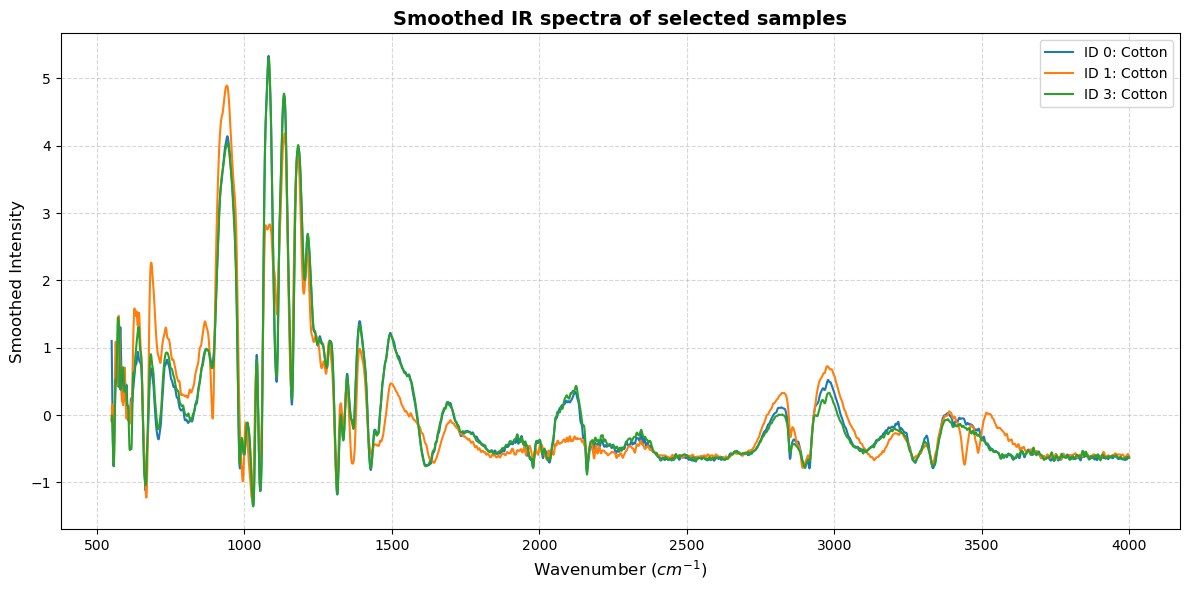

In [ ]:
smoothed_wavenumber_cols = smoothed.columns
smoothed_wavenumbers = smoothed_wavenumber_cols.astype(float)

smoothed_selected_spectra = smoothed.loc[selected_visual_ids, baseline_wavenumber_cols]
smoothed_compare_spectra = smoothed.loc[selected_comparison_ids, baseline_wavenumber_cols]

plt.figure(figsize=(12, 6))
plt.plot(smoothed_wavenumbers, smoothed_selected_spectra.T)
plt.title("Smoothed IR spectra of selected samples", fontsize=14, fontweight='bold')
plt.xlabel("Wavenumber ($cm^{-1}$)", fontsize=12)
plt.ylabel("Smoothed Intensity", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.5)
legend_labels = [f"ID {sid}: {spectrums.loc[sid, 'Labels']}" for sid in selected_visual_ids]
plt.legend(legend_labels, loc="best")
plt.tight_layout()

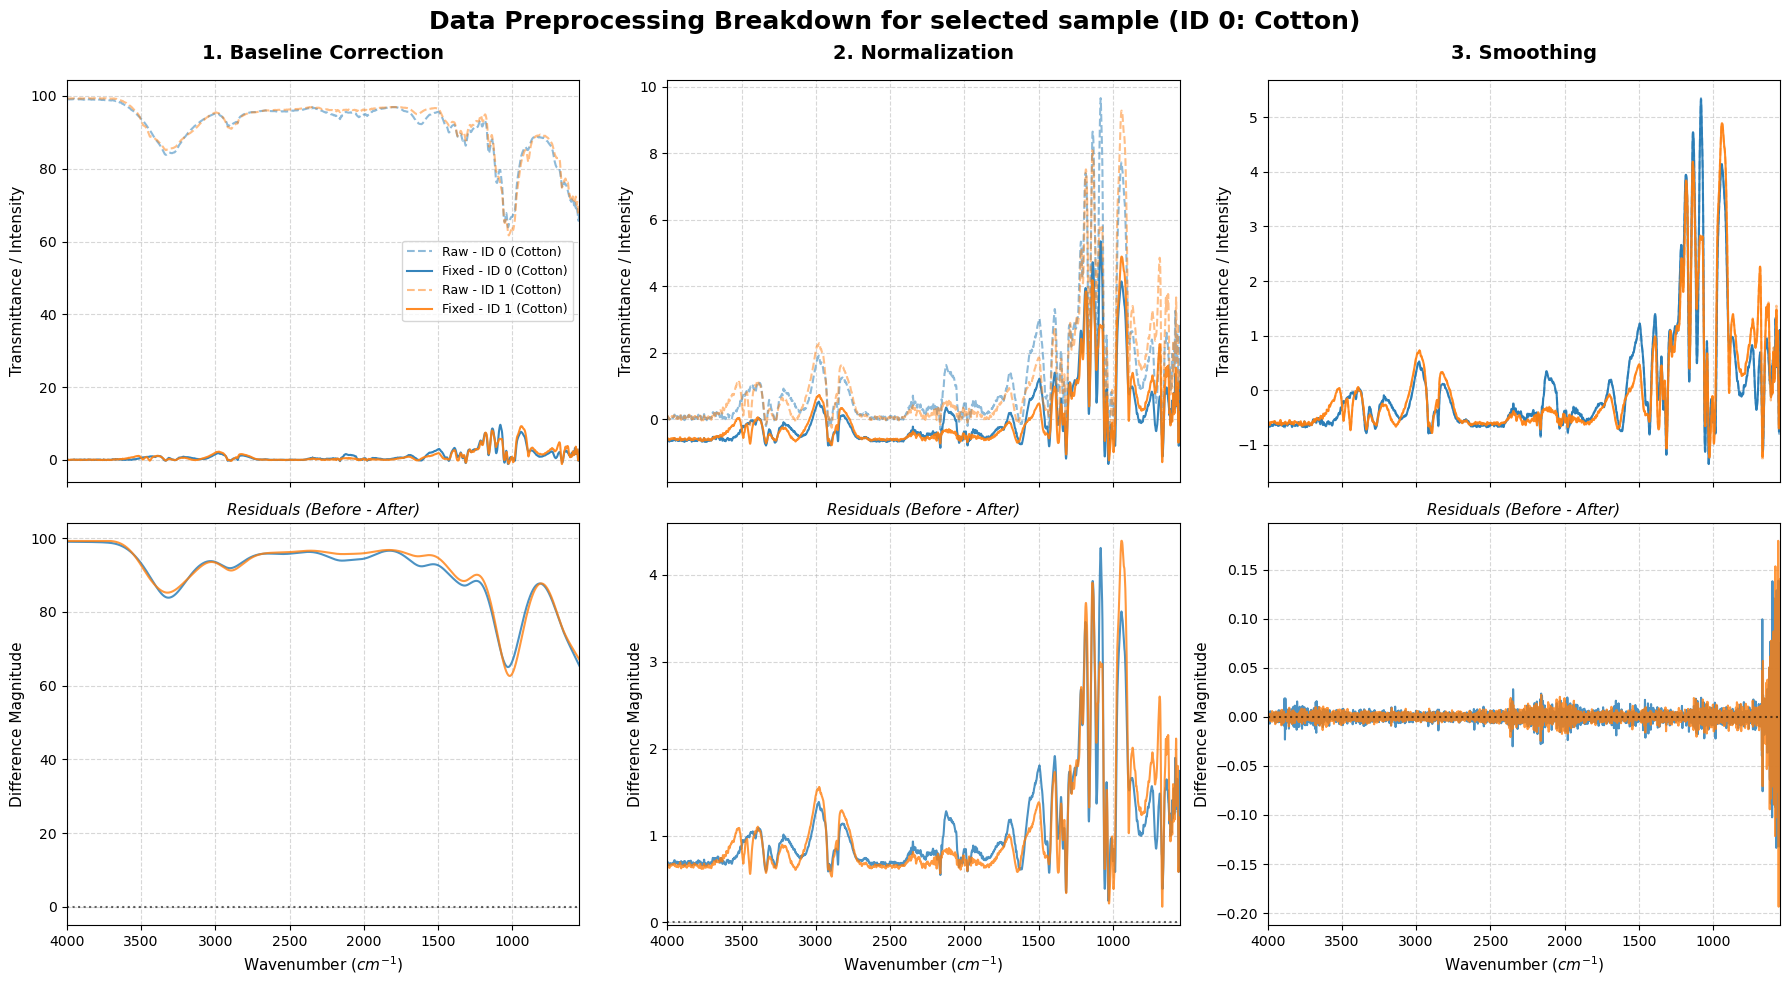

In [38]:
processing_steps = [
    (baseline_compare_spectra, corrected_compare_spectra, "1. Baseline Correction"),
    (corrected_compare_spectra, normalized_compare_spectra, "2. Normalization"),
    (normalized_compare_spectra, smoothed_compare_spectra, "3. Smoothing")
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex=True)

colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for col_idx, (before_df, after_df, step_title) in enumerate(processing_steps):

    ax_top = axes[0, col_idx]
    ax_bottom = axes[1, col_idx]

    for i, sid in enumerate(selected_comparison_ids):

        color = colors[i % len(colors)]
        label_suffix = f"ID {sid} ({spectrums.loc[sid, 'Labels']})"

        y_before = before_df.loc[sid].values
        y_after = after_df.loc[sid].values
        y_residual = y_before - y_after

        if col_idx == 0:
            ax_top.plot(baseline_wavenumbers, y_before, linestyle="--", color=color, alpha=0.5, label=f"Raw - {label_suffix}")
            ax_top.plot(baseline_wavenumbers, y_after, linestyle="-", color=color, alpha=0.9, label=f"Fixed - {label_suffix}")
        else:
            ax_top.plot(baseline_wavenumbers, y_before, linestyle="--", color=color, alpha=0.5)
            ax_top.plot(baseline_wavenumbers, y_after, linestyle="-", color=color, alpha=0.9)

        ax_bottom.plot(baseline_wavenumbers, y_residual, color=color, alpha=0.8)

    ax_top.set_title(step_title, fontsize=14, fontweight='bold', pad=15)
    ax_top.set_ylabel("Transmittance / Intensity", fontsize=11)
    ax_top.grid(True, linestyle="--", alpha=0.5)
    if col_idx == 0:
        ax_top.legend(loc="best", fontsize=9)

    ax_bottom.set_title("Residuals (Before - After)", fontsize=11, style='italic')
    ax_bottom.set_xlabel("Wavenumber ($cm^{-1}$)", fontsize=11)
    ax_bottom.set_ylabel("Difference Magnitude", fontsize=11)
    ax_bottom.grid(True, linestyle="--", alpha=0.5)
    ax_bottom.axhline(0, color='black', linestyle=':', alpha=0.6)

plt.xlim(baseline_wavenumbers.max(), baseline_wavenumbers.min())
fig.suptitle(f"Data Preprocessing Breakdown for selected sample (ID {selected_comparison_ids[0]}: {spectrums.loc[selected_comparison_ids[0], 'Labels']})", fontsize=18, fontweight='bold', y=0.98)

plt.tight_layout()

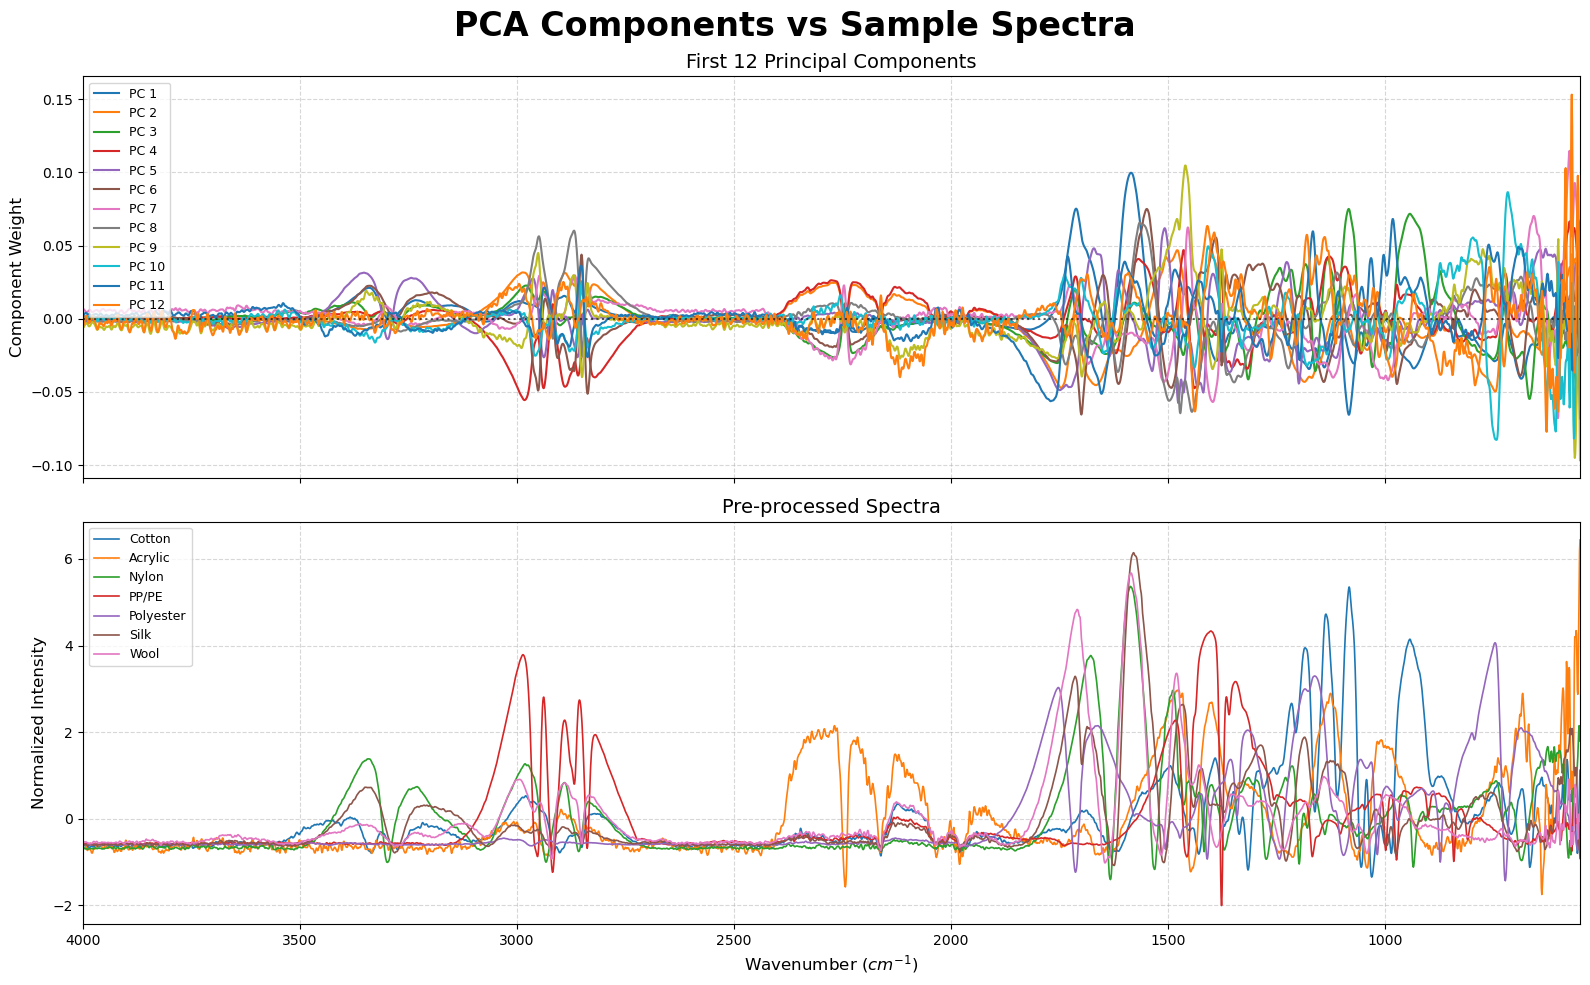

In [96]:
fig, axes = plt.subplots(2, figsize=(16, 10), sharex=True)
axes[0].plot(baseline_wavenumbers, pca_full.components_[:n_components_95].T)
axes[0].axhline(0, color='black', linestyle=':', alpha=0.6)
axes[0].set_title(f"First {n_components_95} Principal Components", fontsize=14)
axes[1].set_xlabel("Wavenumber ($cm^{-1}$)", fontsize=12)
axes[0].set_ylabel("Component Weight", fontsize=12)
axes[0].grid(True, linestyle="--", alpha=0.5)
legend_labels = [f"PC {pcid+1}" for pcid in range(n_components_95)]
axes[0].legend(legend_labels, loc="best", fontsize=9)
axes[0].set_xlim(baseline_wavenumbers.max(), baseline_wavenumbers.min())

for cls in CLASSES:
    i = rep_indices[cls]
    c = CLASS_COLORS[cls]
    axes[1].plot(baseline_wavenumbers, normalized.iloc[i].values.astype(float), color=c, lw=1.2)
axes[1].set_title(f"Pre-processed Spectra", fontsize=14)
axes[1].set_ylabel("Normalized Intensity", fontsize=12)
axes[1].grid(True, linestyle="--", alpha=0.5)
axes[1].legend(CLASSES, loc="best", fontsize=9)

fig.suptitle("PCA Components vs Sample Spectra", fontsize=24, fontweight='bold')
plt.tight_layout()